In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4070


In [3]:
# use GPU if available, otherwise fall back to CPU
# GPU trains neural networks much faster
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [4]:
# neural networks need all miages to be the same size
# and converted to numbers between 0 and 1
transform = transforms.Compose([
    transforms.Resize((224, 224)), #resize every image to 224x224 pixels
    transforms.Grayscale(num_output_channels=3), #convert to 3 channels
    transforms.ToTensor(), #convert image to numbers
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#load images from folders
data_dir = 'data/chest_xray'

train_data = datasets.ImageFolder(f'{data_dir}/train', transform=transform)
test_data = datasets.ImageFolder(f'{data_dir}/test', transform=transform)

# DataLoader feeds images to the model in small batches
# instead of all at once which would crash your RAM
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print('Training images:', len(train_data))
print('Test images:', len(test_data))
print('Classes:', train_data.classes)

Training images: 5216
Test images: 624
Classes: ['NORMAL', 'PNEUMONIA']


In [5]:
# We use a pretrained model called ResNet18
# It was already trained on millions of images so it already
# knows how to detect edges, shapes and textures
# We just retrain the last layer to detect pneumonia instead
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# Replace the last layer with our own
# Original ResNet outputs 1000 classes, we only need 2 (normal/pneumonia)
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to GPU
model = model.to(device)

print('Model ready')

Model ready


In [6]:
# loss function measures how wrong the model is
# weight the normal class higher to handle the imbalance we found
weights = torch.tensor([3.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# optimizer adjusts the model's internal numbers to reduce the loss
# learning rate controls how big each adjustment is
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print('Training setup ready')

Training setup ready


In [7]:
epochs = 5 # number of times to go through the full training set

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # move data to GPU
        images, labels = images.to(device), labels.to(device)

        # forward pass - model makes predictions
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass - model learn from mistakes
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Accuracy: {accuracy:.1f}%')

print('Training complete')


Epoch 1/5 - Loss: 0.1022 - Accuracy: 95.9%
Epoch 2/5 - Loss: 0.0247 - Accuracy: 99.2%
Epoch 3/5 - Loss: 0.0206 - Accuracy: 99.3%
Epoch 4/5 - Loss: 0.0158 - Accuracy: 99.6%
Epoch 5/5 - Loss: 0.0077 - Accuracy: 99.7%
Training complete


In [8]:
model.eval()  # switch to evaluation mode
correct = 0
total = 0

# Track per class accuracy
class_correct = [0, 0]
class_total = [0, 0]

with torch.no_grad():  # don't calculate gradients during testing
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

print(f'Overall test accuracy: {100 * correct / total:.1f}%')
print(f'Normal accuracy: {100 * class_correct[0] / class_total[0]:.1f}%')
print(f'Pneumonia accuracy: {100 * class_correct[1] / class_total[1]:.1f}%')

Overall test accuracy: 79.0%
Normal accuracy: 44.4%
Pneumonia accuracy: 99.7%


In [9]:
# Add stronger class weights and more augmentation
# Augmentation artificially creates more normal images by 
# flipping and rotating existing ones

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),    # randomly flip images
    transforms.RandomRotation(10),         # randomly rotate slightly
    transforms.ColorJitter(brightness=0.2),# vary brightness slightly
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Reload training data with augmentation
train_data = datasets.ImageFolder(f'{data_dir}/train', transform=train_transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# Use stronger class weights
weights = torch.tensor([5.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Reset and retrain model
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print('Setup ready with augmentation and stronger weights')

Setup ready with augmentation and stronger weights


In [10]:
epochs = 5 # number of times to go through the full training set

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # move data to GPU
        images, labels = images.to(device), labels.to(device)

        # forward pass - model makes predictions
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass - model learn from mistakes
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Accuracy: {accuracy:.1f}%')

print('Training complete')

Epoch 1/5 - Loss: 0.1177 - Accuracy: 94.2%
Epoch 2/5 - Loss: 0.0694 - Accuracy: 96.9%
Epoch 3/5 - Loss: 0.0533 - Accuracy: 97.7%
Epoch 4/5 - Loss: 0.0501 - Accuracy: 97.8%
Epoch 5/5 - Loss: 0.0379 - Accuracy: 98.4%
Training complete


In [11]:
model.eval()  # switch to evaluation mode
correct = 0
total = 0

# Track per class accuracy
class_correct = [0, 0]
class_total = [0, 0]

with torch.no_grad():  # don't calculate gradients during testing
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

print(f'Overall test accuracy: {100 * correct / total:.1f}%')
print(f'Normal accuracy: {100 * class_correct[0] / class_total[0]:.1f}%')
print(f'Pneumonia accuracy: {100 * class_correct[1] / class_total[1]:.1f}%')

Overall test accuracy: 92.5%
Normal accuracy: 84.2%
Pneumonia accuracy: 97.4%


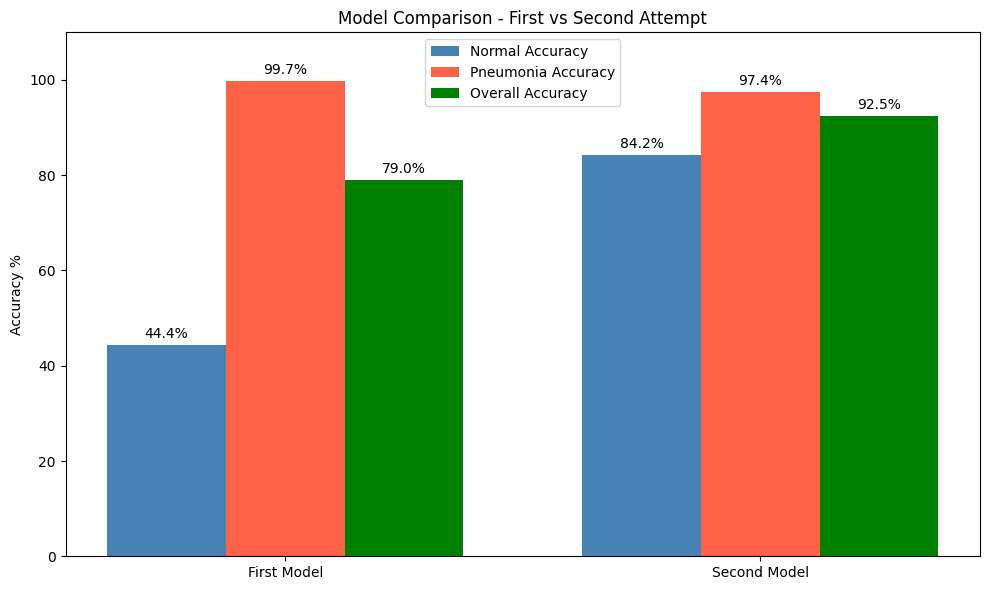

In [12]:
# visualize results comparison
models_names = ['First Model', 'Second Model']
normal_acc = [44.4, 84.2]
pneumonia_acc = [99.7, 97.4]
overall_acc = [79.0, 92.5]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, normal_acc, width, label='Normal Accuracy', color='steelblue')
ax.bar(x, pneumonia_acc, width, label='Pneumonia Accuracy', color='tomato')
ax.bar(x + width, overall_acc, width, label='Overall Accuracy', color='green')

ax.set_ylabel('Accuracy %')
ax.set_title('Model Comparison - First vs Second Attempt')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend()
ax.set_ylim(0, 110)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()